In [1]:
import arviz.preview as az
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from xarray import open_datatree

jax.config.update("jax_enable_x64", True)

In [2]:
NUM_POPS = 5

In [3]:
plt.rcParams.update({
    "font.family":         "sans-serif",
    "font.size":           24,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.labelsize":      24,
    "legend.fontsize":     20,
    "xtick.labelsize":     20,
    "ytick.labelsize":     20,
})

## RDM

In [4]:
dt_dict_rdm_approx = {}

for i in range(NUM_POPS):
    dt_path = f"../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/hierarchical_recovery_pop{i}_approx.nc"
    dt_dict_rdm_approx[i] = open_datatree(dt_path)

dt_dict_rdm_ref = {}

for i in range(NUM_POPS):
    dt_path = f"../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/hierarchical_recovery_pop{i}_ref.nc"
    dt_dict_rdm_ref[i] = open_datatree(dt_path)


In [5]:
pop_coord = xr.DataArray(np.arange(NUM_POPS), dims="pop")                                                                                                                                       
                                                                                                                                                                                              
def merge_datatrees(dt_dict):
    # Groups with consistent dims — can concat directly                                                                                                                                         
    groups = ["posterior", "constant_data", "prior"]                                                                                                                                            
                                                                                                                                                                                                
    dt_merged = xr.DataTree.from_dict({                                                                                                                                                            
        group: xr.concat(                                                                                                                                                                       
            [dt_dict[i][group].ds for i in range(NUM_POPS)],                                                                                                                                            
            dim=pop_coord                                                                                                                                                                   
        )                                                                                                                                                                                       
        for group in groups                                                                                                                                                                     
    })

    dt_merged.attrs = dt_dict[0].attrs

    return dt_merged

In [6]:
RHAT_THRESHOLD = 1.05


def mask_bad_params(dt, threshold=RHAT_THRESHOLD):
    posterior = dt["posterior"].ds
    rhat_ds = az.rhat(posterior)

    masked_posterior = posterior.copy()
    for var in rhat_ds.data_vars:
        valid = rhat_ds[var] < threshold
        print("Converged parameters: ", valid.sum().item(), valid.mean().item())
        masked_posterior[var] = posterior[var].where(valid)


    new_dt = xr.DataTree.from_dict({
        "posterior": masked_posterior,
        "constant_data": dt["constant_data"].ds,
        "prior": dt["prior"].ds,
    })
    new_dt.attrs = dt.attrs
    return new_dt

In [7]:
dt_merged_rdm_approx = mask_bad_params(merge_datatrees(dt_dict_rdm_approx))
dt_merged_rdm_ref = mask_bad_params(merge_datatrees(dt_dict_rdm_ref))

Converged parameters:  25 1.0
Converged parameters:  25 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  25 1.0
Converged parameters:  25 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0


In [8]:
def stack_posterior_subject(dt):
    return (dt["posterior"].ds[dt.param_names]
        .to_array(dim="param")                                                                         
        .to_dataset(name="theta")                                                                                                                
    ).merge(dt["constant_data"].ds[["theta"]].rename({"theta": "true"}))

In [9]:
posterior_stacked_subject_rdm_approx = stack_posterior_subject(dt_merged_rdm_approx)
posterior_stacked_subject_rdm_ref = stack_posterior_subject(dt_merged_rdm_ref)

In [10]:
def calc_posterior_median_df(posterior_stacked):
    return (posterior_stacked
        .median(dim=["chain", "draw"])
    ).to_dataframe().reset_index()


def calc_posterior_ci_df(posterior_stacked, q_low=0.025, q_high=0.975):
    quantiles = posterior_stacked.theta.quantile(
        [q_low, 0.5, q_high], dim=["chain", "draw"]
    )
    return (
        xr.Dataset({
            "lower": quantiles.sel(quantile=q_low, drop=True),
            "theta": quantiles.sel(quantile=0.5, drop=True),
            "upper": quantiles.sel(quantile=q_high, drop=True),
        })
        .merge(posterior_stacked.true)
        .to_dataframe()
        .reset_index()
    )


def add_recovery_ci(data, x="true", **kwargs):
    ax = plt.gca()
    yerr = np.vstack([
        data["theta"] - data["lower"],
        data["upper"] - data["theta"],
    ])
    ax.errorbar(
        data[x], data["theta"], yerr=yerr,
        fmt="none", ecolor="gray", elinewidth=1.0, alpha=0.5, zorder=0,
    )


def add_cross_recovery_ci(data, **kwargs):
    ax = plt.gca()
    xerr = np.vstack([
        data["theta_ref"] - data["lower_ref"],
        data["upper_ref"] - data["theta_ref"],
    ])
    yerr = np.vstack([
        data["theta_approx"] - data["lower_approx"],
        data["upper_approx"] - data["theta_approx"],
    ])
    ax.errorbar(
        data["theta_ref"], data["theta_approx"], xerr=xerr, yerr=yerr,
        fmt="none", ecolor="gray", elinewidth=0.5, alpha=0.4, zorder=0,
    )

In [11]:
df_posterior_median_subject_rdm_approx = calc_posterior_median_df(posterior_stacked_subject_rdm_approx)
df_posterior_median_subject_rdm_ref = calc_posterior_median_df(posterior_stacked_subject_rdm_ref)

df_posterior_median_subject_rdm_join = df_posterior_median_subject_rdm_approx.merge(
    df_posterior_median_subject_rdm_ref,
    on=["subject", "pop", "param"],
    suffixes=["_approx", "_ref"]
)

df_posterior_ci_subject_rdm_join = calc_posterior_ci_df(posterior_stacked_subject_rdm_approx).merge(
    calc_posterior_ci_df(posterior_stacked_subject_rdm_ref),
    on=["subject", "pop", "param", "true"],
    suffixes=["_approx", "_ref"],
)

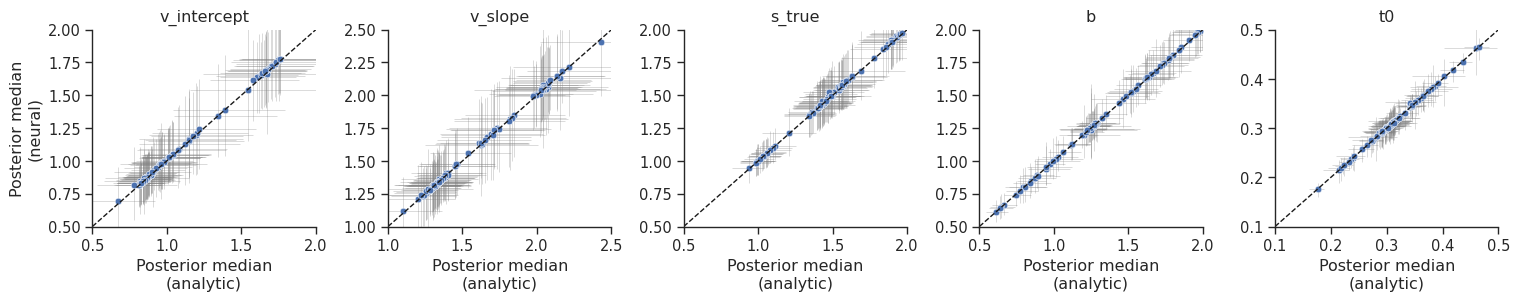

In [12]:
sns.set_theme(context="paper", style="ticks", font_scale=1.2)

g = sns.FacetGrid(df_posterior_ci_subject_rdm_join, col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(add_cross_recovery_ci)
g.map_dataframe(sns.scatterplot, x="theta_ref", y="theta_approx")

g.set_xlabels(label="Posterior median\n(analytic)")
g.set_ylabels(label="Posterior median\n(neural)")

g.set_titles(col_template="{col_name}")

lims_dict = {
    "v_intercept": (0.5, 2.0),
    "v_slope": (1.0, 2.5),
    "s_true": (0.5, 2.0),
    "b": (0.5, 2.0),
    "t0": (0.1, 0.5),
}

for (col_val), ax in g.axes_dict.items():

    ax.set_xlim(lims_dict[col_val])
    ax.set_ylim(lims_dict[col_val])
    ax.plot(lims_dict[col_val], lims_dict[col_val], 'k--', lw=1)

g.savefig("parameter_recovery/parameter_cross_recovery_hierarchical_subject_rdm.png")

In [13]:
def stack_posterior_pop(dt):
    df = (dt["posterior"].ds[["mu", "sigma"]]
        .to_array(dim="pop_param")                                                                         
        .to_dataset(name="theta")                                                                                                             
    ).merge(dt["constant_data"].ds[["mu", "sigma"]].to_array(dim="pop_param").to_dataset(name="true"))

    df["true"] = xr.where(df["pop_param"] == "mu", np.exp(df.true), df.true)

    return df

In [14]:
posterior_stacked_pop_rdm_approx = stack_posterior_pop(dt_merged_rdm_approx)
posterior_stacked_pop_rdm_ref = stack_posterior_pop(dt_merged_rdm_ref)

In [15]:
df_posterior_median_pop_rdm_approx = calc_posterior_median_df(posterior_stacked_pop_rdm_approx)
df_posterior_median_pop_rdm_ref = calc_posterior_median_df(posterior_stacked_pop_rdm_ref)

df_posterior_median_pop_rdm_join = df_posterior_median_pop_rdm_approx.merge(
    df_posterior_median_pop_rdm_ref,
    on=["pop", "param", "pop_param"],
    suffixes=["_approx", "_ref"]
)

df_posterior_ci_pop_rdm_join = calc_posterior_ci_df(posterior_stacked_pop_rdm_approx).merge(
    calc_posterior_ci_df(posterior_stacked_pop_rdm_ref),
    on=["pop", "param", "pop_param", "true"],
    suffixes=["_approx", "_ref"],
)

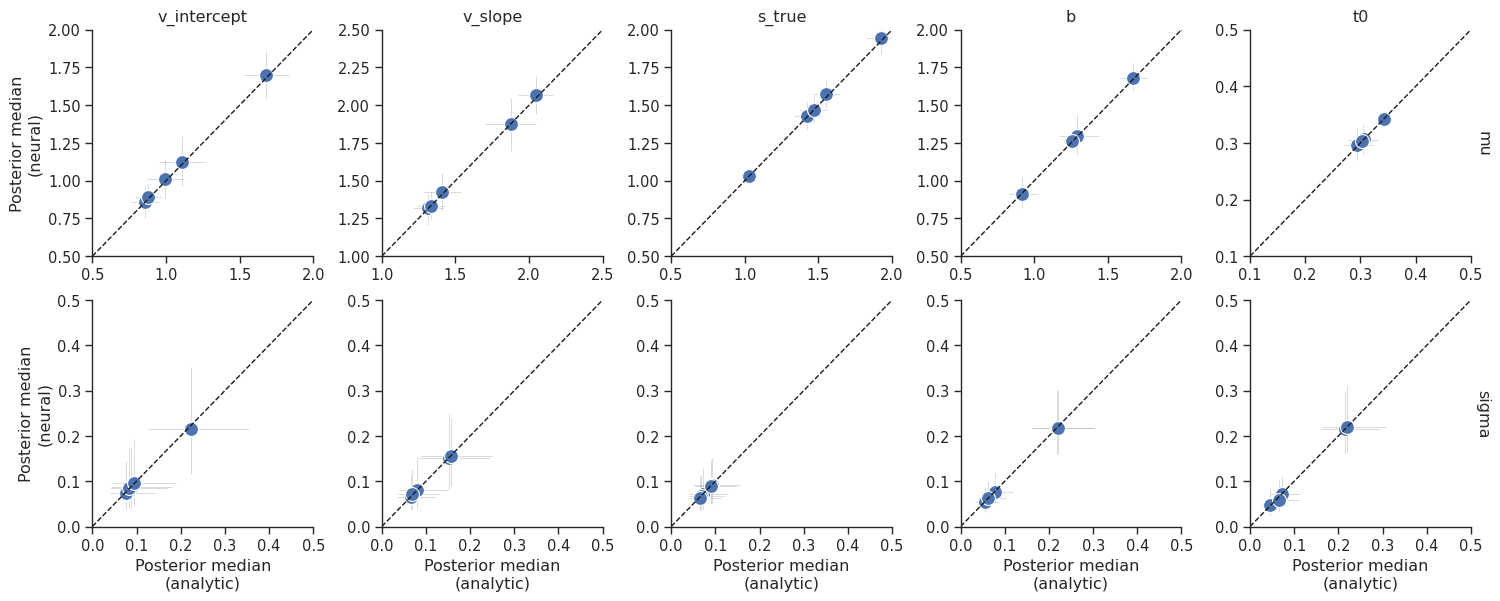

In [16]:
g = sns.FacetGrid(df_posterior_ci_pop_rdm_join, row="pop_param", col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(add_cross_recovery_ci)
g.map_dataframe(sns.scatterplot, x="theta_ref", y="theta_approx", s=100.0)

g.set_xlabels(label="Posterior median\n(analytic)")
g.set_ylabels(label="Posterior median\n(neural)")

g.set_titles(row_template="{row_name}", col_template="{col_name}")

lims_dict = {
    "v_intercept": (0.5, 2.0),
    "v_slope": (1.0, 2.5),
    "s_true": (0.5, 2.0),
    "b": (0.5, 2.0),
    "t0": (0.1, 0.5),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val == "mu":
        xlim = lims_dict[col_val]
        ylim = lims_dict[col_val]
    else:
        xlim = (0, 0.5)
        ylim = (0, 0.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.plot(xlim, ylim, 'k--', lw=1)

g.savefig("parameter_recovery/parameter_cross_recovery_hierarchical_pop_rdm.png")

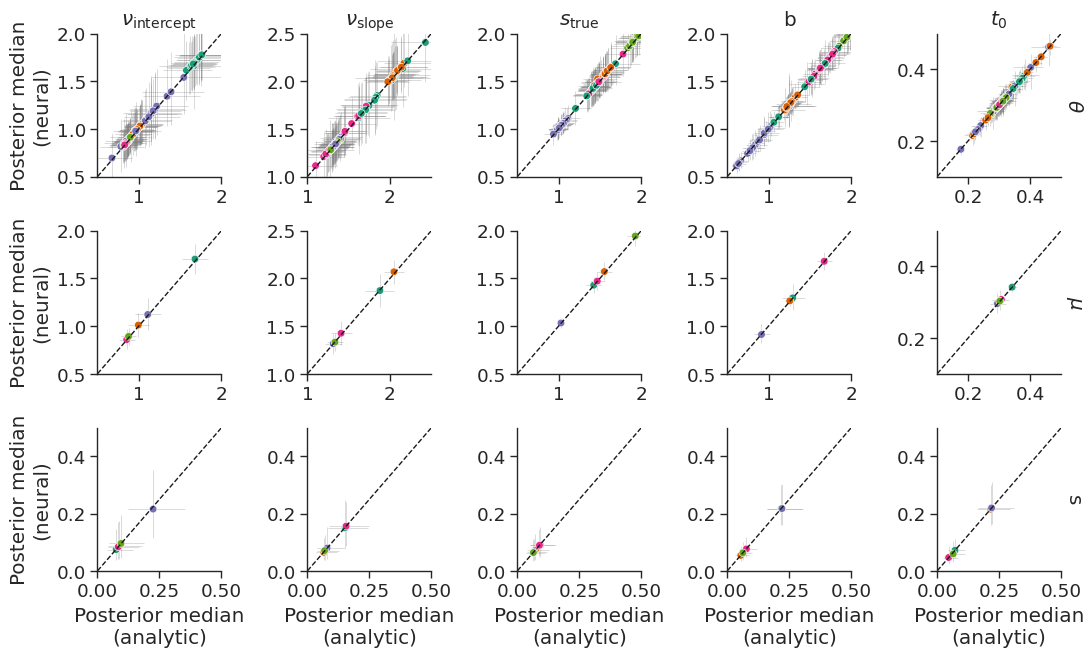

In [17]:
sns.set_theme(context="paper", style="ticks", font_scale=1.5)

df_posterior_ci_subject_rdm_join["pop_param"] = "theta"

df_posterior_ci_rdm_join = pd.concat([
    df_posterior_ci_subject_rdm_join,
    df_posterior_ci_pop_rdm_join,
])

param_labels = {
    "v_intercept": r"$\nu_\text{intercept}$",
    "v_slope": r"$\nu_\text{slope}$",
    "s_true": r"$s_\text{true}$",
    "t0": r"$t_0$",
}

pop_param_labels = {
    "theta": r"$\theta$",
    "mu": r"$\mu$",
    "sigma": "s",
}

df_posterior_ci_rdm_join["param"] = df_posterior_ci_rdm_join["param"].replace(param_labels)
df_posterior_ci_rdm_join["pop_param"] = df_posterior_ci_rdm_join["pop_param"].replace(pop_param_labels)

g = sns.FacetGrid(df_posterior_ci_rdm_join, row="pop_param", col="param", sharex=False, sharey=False, margin_titles=True, height=2.2)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(add_cross_recovery_ci)
g.map_dataframe(sns.scatterplot, x="theta_ref", y="theta_approx", hue="pop", palette="Dark2", s=30)

g.set_xlabels(label="Posterior median\n(analytic)")
g.set_ylabels(label="Posterior median\n(neural)")

g.set_titles(row_template="{row_name}", col_template="{col_name}")

lims_dict = {
    r"$\nu_\text{intercept}$": (0.5, 2.0),
    r"$\nu_\text{slope}$": (1.0, 2.5),
    r"$s_\text{true}$": (0.5, 2.0),
    "b": (0.5, 2.0),
    r"$t_0$": (0.1, 0.5),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val in (r"$\theta$", r"$\mu$"):
        xlim = lims_dict[col_val]
        ylim = lims_dict[col_val]
    else:
        xlim = (0, 0.5)
        ylim = (0, 0.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.plot(xlim, ylim, 'k--', lw=1)

g.savefig("parameter_recovery/parameter_recovery_hierarchical_rdm.png")

In [18]:
df_posterior_subject_cor = (df_posterior_median_subject_rdm_join
    .drop(["subject", "pop"], axis=1)
    .groupby(["param"])
    .corr()
    .iloc[0::4,-2]
    .reset_index()
    .drop(["level_1"], axis=1)
)

df_posterior_subject_cor["pop_param"] = "subject"

In [19]:
df_posterior_pop_cor = (df_posterior_median_pop_rdm_join
    .drop(["pop"], axis=1)
    .groupby(["param", "pop_param"])
    .corr()
    .iloc[0::4,-2]
    .reset_index()
    .drop(["level_2"], axis=1)
)

df_posterior_cor = (pd.concat([
    df_posterior_subject_cor,
    df_posterior_pop_cor
], axis=0)
    .pivot(index="pop_param", columns=["param"])
)

print(df_posterior_cor.to_latex(float_format="%.4f"))

\begin{tabular}{lrrrrr}
\toprule
 & \multicolumn{5}{r}{theta_ref} \\
param & b & s_true & t0 & v_intercept & v_slope \\
pop_param &  &  &  &  &  \\
\midrule
mu & 1.0000 & 0.9999 & 0.9998 & 0.9999 & 0.9994 \\
sigma & 1.0000 & 0.9982 & 0.9997 & 0.9998 & 0.9996 \\
subject & 0.9999 & 0.9997 & 0.9996 & 0.9997 & 0.9995 \\
\bottomrule
\end{tabular}



## CRDM

In [20]:
dt_dict_crdm_approx = {}

for i in range(NUM_POPS):
    dt_path = f"../outputs/crdm/model.num_bins=12/model.num_mid=128/model.sampler.dt=0.0005/optimizer=adam_cosine_decay/train_steps=1000000/hierarchical_recovery_pop{i}_approx.nc"
    dt_dict_crdm_approx[i] = open_datatree(dt_path)


In [21]:
dt_merged_crdm_approx = mask_bad_params(merge_datatrees(dt_dict_crdm_approx))

Converged parameters:  35 1.0
Converged parameters:  35 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0
Converged parameters:  100 1.0


In [22]:
posterior_stacked_subject_crdm_approx = stack_posterior_subject(dt_merged_crdm_approx)

In [23]:
df_posterior_median_subject_crdm_approx = calc_posterior_median_df(posterior_stacked_subject_crdm_approx)
df_posterior_ci_subject_crdm_approx = calc_posterior_ci_df(posterior_stacked_subject_crdm_approx)

In [24]:
def calc_posterior_median_true_correlation(df):
    return (df
        .drop(["subject", "pop"], axis=1)
        .groupby(["param"])
        .corr()
        .iloc[0::2,-1]
        .reset_index()
    )

df_cor_crdm_approx = calc_posterior_median_true_correlation(df_posterior_median_subject_crdm_approx)

In [25]:
posterior_stacked_pop_crdm_approx = stack_posterior_pop(dt_merged_crdm_approx)

In [26]:
df_posterior_median_pop_crdm_approx = calc_posterior_median_df(posterior_stacked_pop_crdm_approx)
df_posterior_ci_pop_crdm_approx = calc_posterior_ci_df(posterior_stacked_pop_crdm_approx)

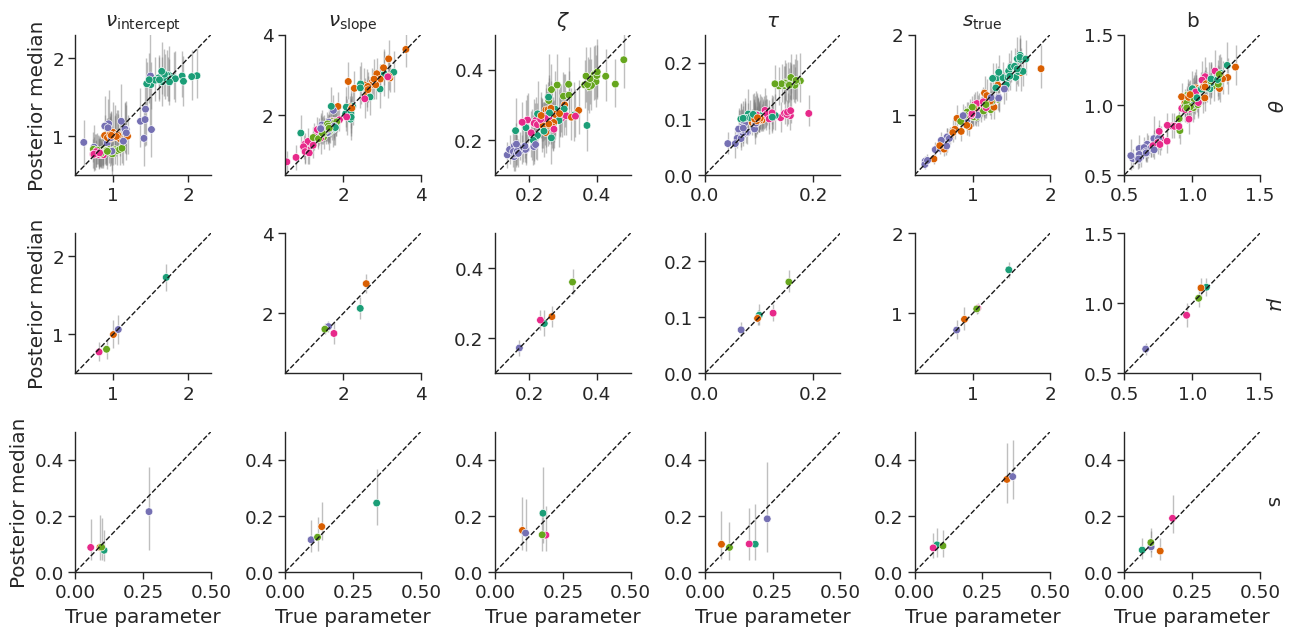

In [27]:
sns.set_theme(context="paper", style="ticks", font_scale=1.5)

df_posterior_ci_subject_crdm_approx["pop_param"] = "theta"

df_posterior_ci_crdm_approx = pd.concat([
    df_posterior_ci_subject_crdm_approx,
    df_posterior_ci_pop_crdm_approx,
])

param_labels = {
    "v_c_intercept": r"$\nu_\text{intercept}$",
    "v_c_slope": r"$\nu_\text{slope}$",
    "amp": r"$\zeta$",
    "tau": r"$\tau$",
    "s_true": r"$s_\text{true}$",
    "t0": r"$t_0$",
}

pop_param_labels = {
    "theta": r"$\theta$",
    "mu": r"$\mu$",
    "sigma": "s",
}

df_posterior_ci_crdm_approx["param"] = df_posterior_ci_crdm_approx["param"].replace(param_labels)
df_posterior_ci_crdm_approx["pop_param"] = df_posterior_ci_crdm_approx["pop_param"].replace(pop_param_labels)

g = sns.FacetGrid(df_posterior_ci_crdm_approx.loc[df_posterior_ci_crdm_approx["param"] != r"$t_0$", :], row="pop_param", col="param", sharex=False, sharey=False, margin_titles=True, height=2.2)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(add_recovery_ci, x="true")
g.map_dataframe(sns.scatterplot, x="true", y="theta", hue="pop", palette="Dark2", s=30)

g.set_xlabels(label="True parameter")
g.set_ylabels(label="Posterior median")

g.set_titles(row_template="{row_name}", col_template="{col_name}")

lims_dict = {
    r"$\nu_\text{intercept}$": (0.5, 2.3),
    r"$\nu_\text{slope}$": (0.5, 4.0),
    r"$\zeta$": (0.1, 0.5),
    r"$\tau$": (0, 0.25),
    r"$s_\text{true}$": (0.25, 2.0),
    "b": (0.5, 1.5),
    r"$t_0$": (0.15, 0.5),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val in (r"$\theta$", r"$\mu$"):
        xlim = lims_dict[col_val]
        ylim = lims_dict[col_val]
    else:
        xlim = (0, 0.5)
        ylim = (0, 0.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.plot(xlim, ylim, 'k--', lw=1)

g.savefig("parameter_recovery/parameter_recovery_hierarchical_crdm.png")

In [28]:
posterior_stacked_pop_crdm_approx = stack_posterior_pop(dt_merged_crdm_approx)

In [29]:
df_posterior_median_pop_crdm_approx = calc_posterior_median_df(posterior_stacked_pop_crdm_approx)
df_posterior_ci_pop_crdm_approx = calc_posterior_ci_df(posterior_stacked_pop_crdm_approx)

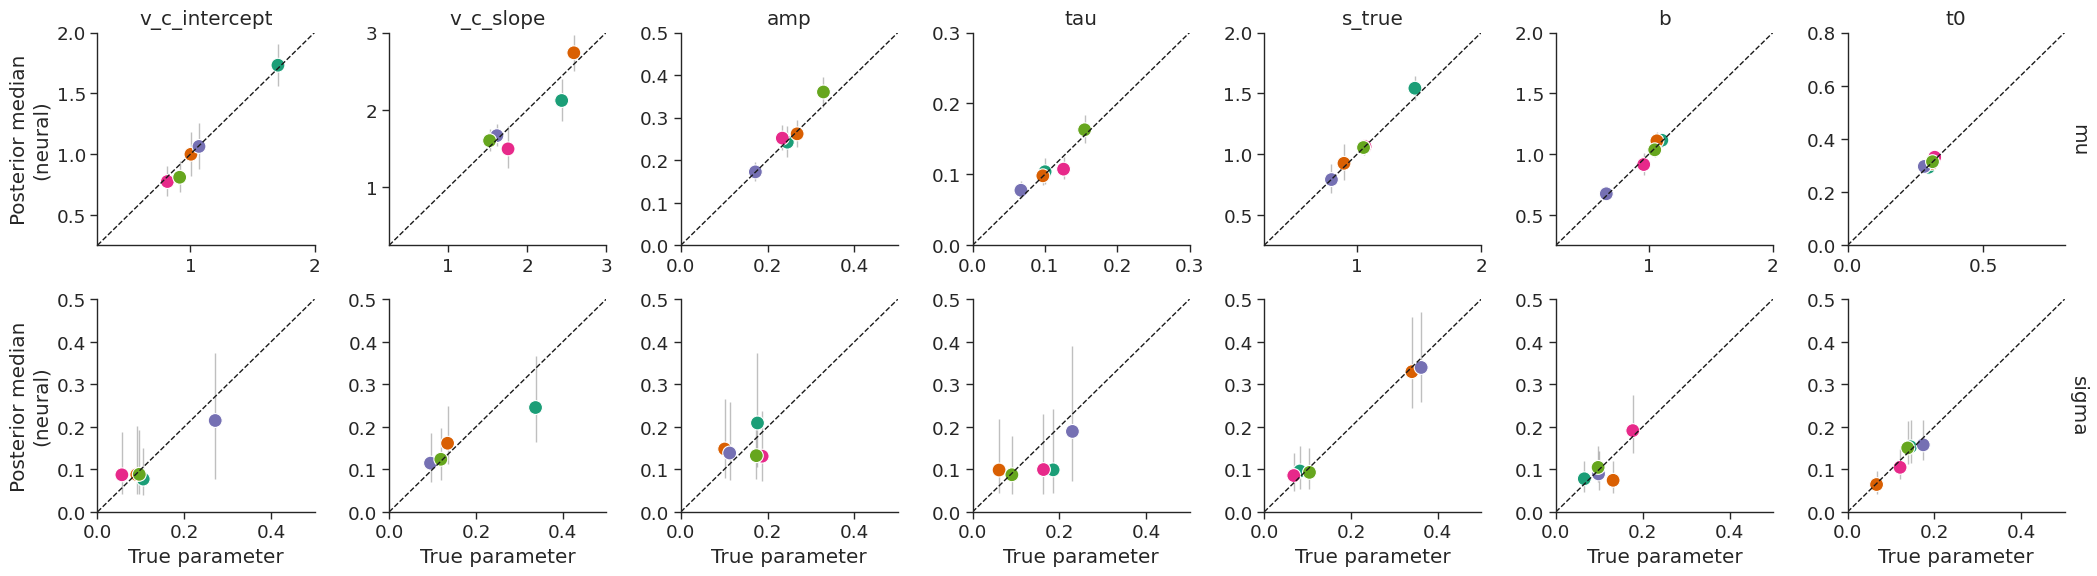

In [30]:
g = sns.FacetGrid(df_posterior_ci_pop_crdm_approx, row="pop_param", col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(add_recovery_ci, x="true")
g.map_dataframe(sns.scatterplot, x="true", y="theta", s=100.0, hue="pop", palette="Dark2")

g.set_xlabels(label="True parameter")
g.set_ylabels(label="Posterior median\n(neural)")

g.set_titles(row_template="{row_name}", col_template="{col_name}")

lims_dict = {
    "v_c_intercept": (0.25, 2.0),
    "v_c_slope": (0.25, 3.0),
    "amp": (0, 0.5),
    "tau": (0, 0.3),
    "s_true": (0.25, 2.0),
    "b": (0.25, 2.0),
    "t0": (0, 0.8),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val == "mu":
        xlim = lims_dict[col_val]
        ylim = lims_dict[col_val]
    else:
        xlim = (0, 0.5)
        ylim = (0, 0.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.plot(xlim, ylim, 'k--', lw=1)

g.savefig("parameter_recovery/parameter_recovery_hierarchical_pop_crdm.png")